# Introduction to PyGMT

---


## Preliminaries

1. Open this notebook using the following link: [https://bit.ly/introtopygmt2026](https://bit.ly/introtopygmt2026)

2. Please save a copy of this Jupyter Notebook to your own Google Drive first by selecting "File"->"Save a copy in Drive". This should open a copy of this notebook in a new tab.

3. Once you've opened your own copy of this notebook, to execute a code cell below, select it and type `Shift + Enter` or place your cursor to the left of each cell until the "Run" ► button appears, and then click it.

## Installing PyGMT and its dependencies on Google Colab

Google Colab does not come with PyGMT and its dependencies pre-installed. To use them, we need to follow the steps below to install them manually.

1. First, we must install the `gmt` binaries and libraries  on Google Colab. Then, we must install `pygmt` using `pip`. Note that as of 02 March 2026, only `pygmt` version 0.16.0 is compatible with the `gmt` binaries that can be installed in a Google Colab runtime. This step may take a few minutes, so please wait.

In [ ]:
!sudo apt-get update
!sudo apt-get install libgmt-dev gmt ghostscript

!pip install pygmt==0.16.0

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [3,081 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,307 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,046 kB]
Hi

2. Next, let's verify the installation of the `gmt` binaries:

In [ ]:
!which gmt

/usr/bin/gmt


## Loading the PyGMT package

1. Hopefully we can now import the `pygmt` package into the Google Colab environment. The cell below only needs to be run once:

In [ ]:
import pygmt

2. Let's check the installation:

In [ ]:
pygmt.show_versions()

PyGMT information:
  version: v0.16.0
System information:
  python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
  executable: /usr/bin/python3
  machine: Linux-6.6.122+-x86_64-with-glibc2.35
Dependency information:
  numpy: 2.0.2
  pandas: 2.2.2
  xarray: 2025.12.0
  packaging: 26.2
  contextily: None
  geopandas: 1.1.3
  IPython: 7.34.0
  pyarrow: 18.1.0
  rioxarray: None
  gdal: 3.8.4
  ghostscript: 9.55.0
GMT library information:
  version: 6.4.0
  padding: 2
  share dir: /usr/share/gmt
  plugin dir: /usr/lib/x86_64-linux-gnu/gmt/plugins
  library path: /usr/lib/x86_64-linux-gnu/libgmt.so
  cores: 2
  grid layout: rows
  image layout: 
  binary version: 6.4.0


## Example 1

To make figures in PyGMT we will mainly be using methods of the `pygmt.Figure` class.

1. Let's begin by creating an instance of `pygmt.Figure`

In [ ]:
fig1a = pygmt.Figure()

2. We build up layers and elements to the figure using methods. For our first example, let's make a global map of coastlines that is 12 cm wide using the Mollweide projection (**W**). We can also add a frame with grid lines and tick marks. **NOTE**: running just `fig.coast` will generate the figure, but we need `fig.show()` to display it:

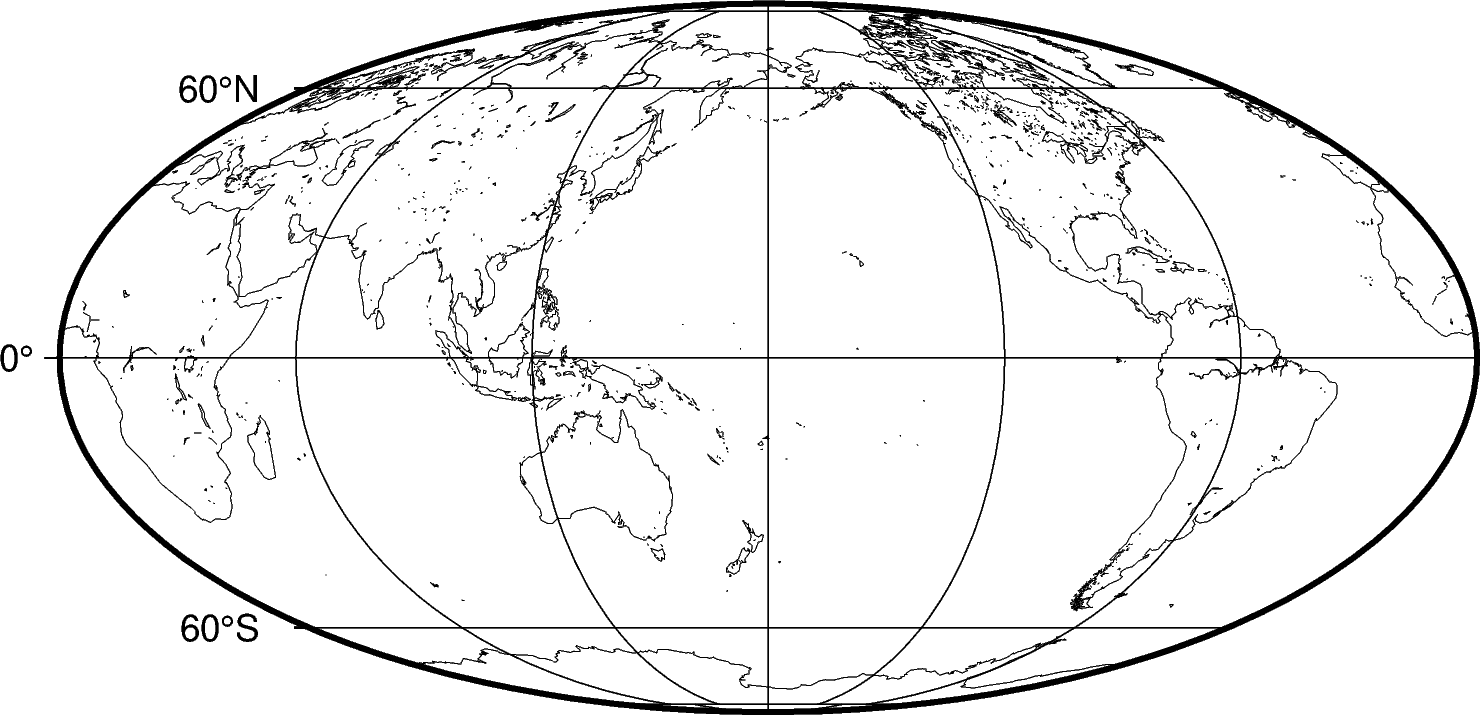

In [ ]:
fig1a.coast(region='g', # g = entire globe ; map bounds of entire globe from 0°-360° longitude, 90°-90° latitude centered at International Date Line
           projection='W12c', # W = global map of coastlines thats 12 cm wide using Mollweide projection
           frame="ag", # a= annotations and g=gridlines for the axes, automatically
           shorelines=0.1) # shorelines are 0.1 thick
fig1a.show()

3. We can also add shading to the land and water areas:

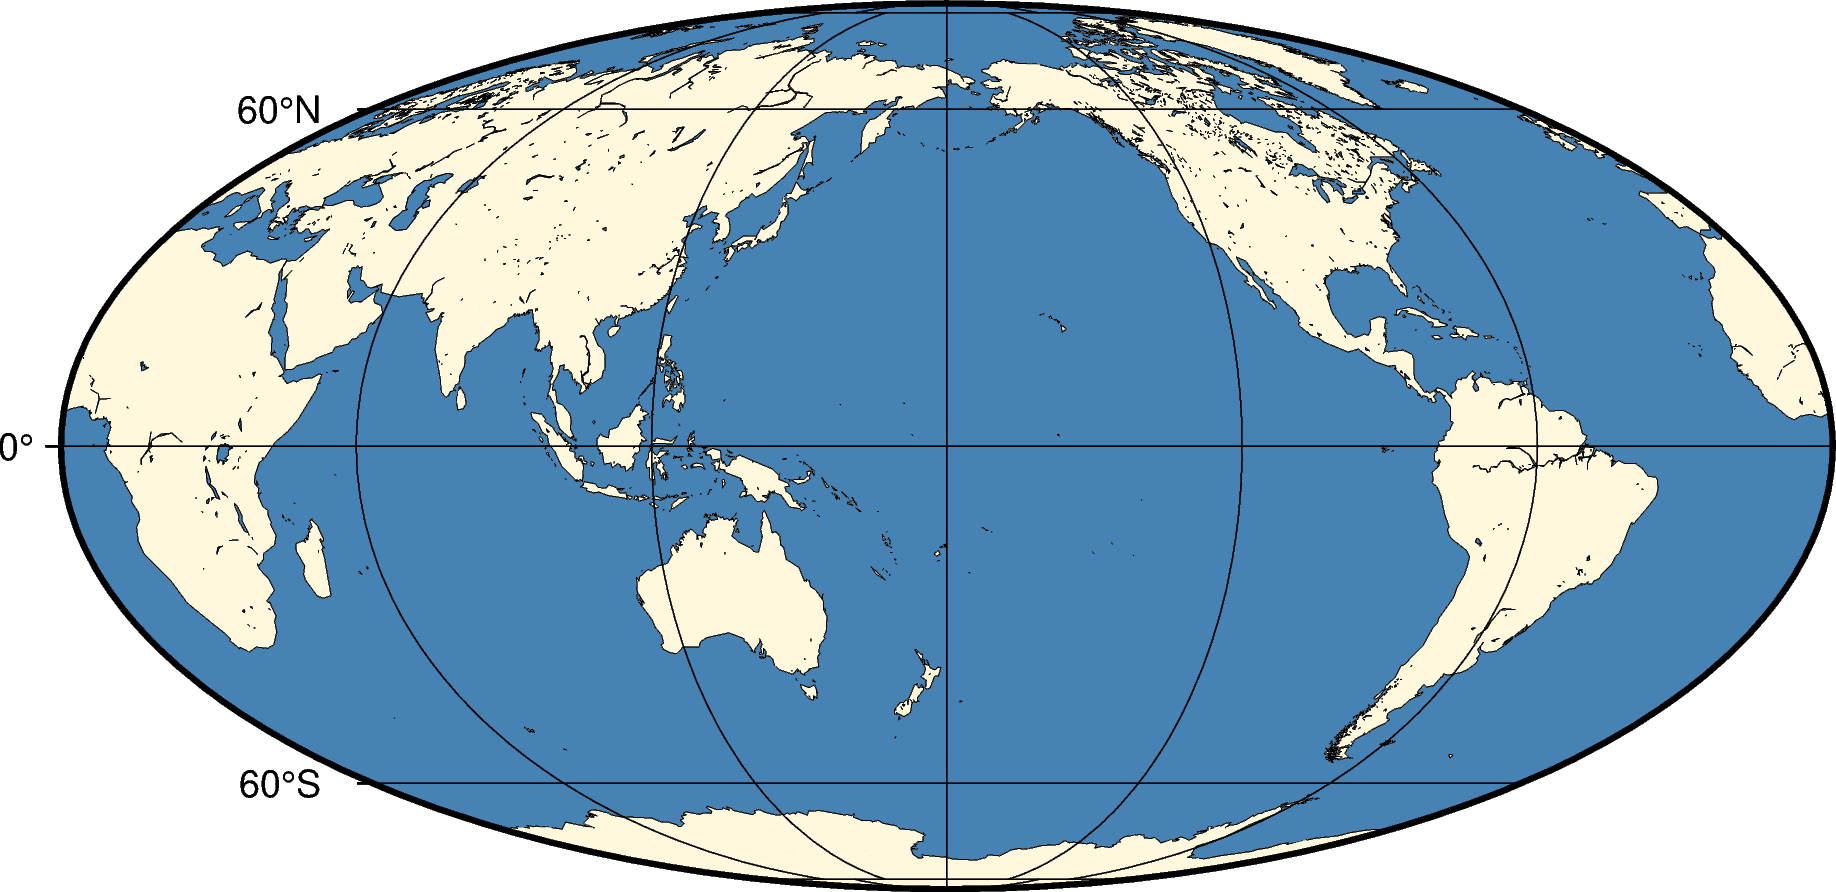

In [ ]:
fig1b = pygmt.Figure()
fig1b.coast(region='g',
           projection='W15c', # W15c = Mollweide projection, 4 cm width of the map
           frame="ag",
           shorelines=0.1,
           land="cornsilk",   # land shading
           water="steelblue") # water shading
fig1b.show()

## Example 2

1. Let's try making a map of a smaller region. For example we can use ISO country codes in `region`, so let's see for the Philippines:

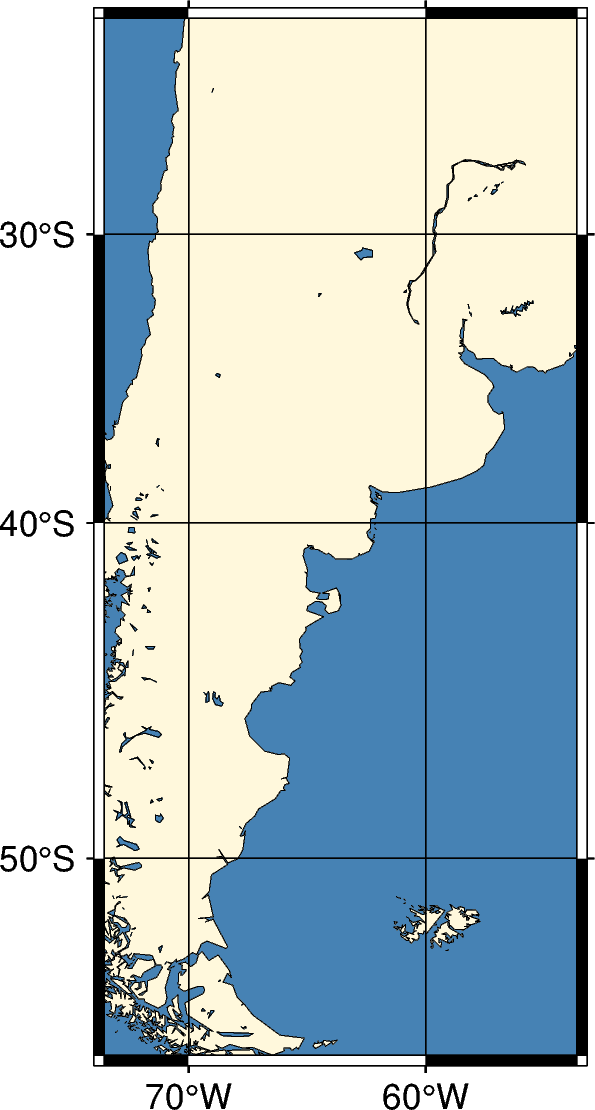

In [ ]:
fig2a = pygmt.Figure()
fig2a.coast(region='AR', # AR = argentina map
           projection='M4c', # M4c = Mercator projection, 4 cm width of the map
           frame="ag",
           shorelines=0.1,
           land="cornsilk",
           water="steelblue")
fig2a.show()

# notes
# Mollweide projection - equal-area map, preserves the real sizes, distorts their shapes
# Mercator projection - preserves true shapes and angles, drastically distorts sizes, regions near poles appear enlarge

2. The region can also be specified using a set of coordinates, in this case `[121.5, 126, 8.5, 13]` corresponds to the [*west longitude, east longitude, south latitude, north latitude*]

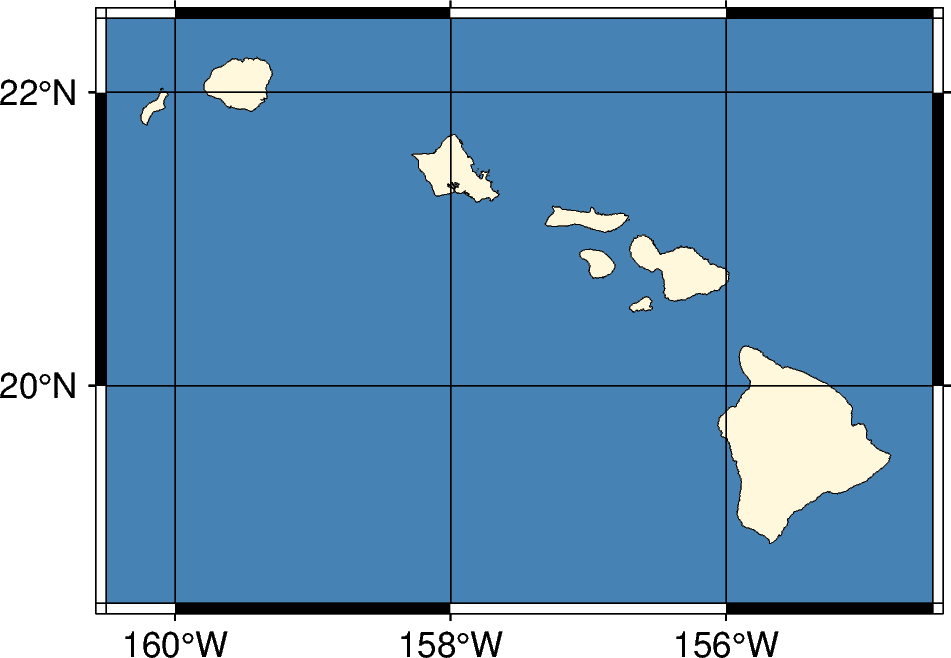

In [ ]:
fig2b = pygmt.Figure()
fig2b.coast(region=[-160.5, -154.5, 18.5, 22.5], # hawaii islands coordinates [west longitude, east longitude, south latitude, north latitude]
           projection='M7c',
           frame="ag",
           shorelines=0.1,
           land="cornsilk",
           water="steelblue")
fig2b.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


3. You can save the figure to a file by using the `savefig` method.

In [ ]:
fig2b.savefig('hawaii_islands.png')

## Example 3

PyGMT also has some built-in datasets, such as topographic relief:

grdblend [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]
grdblend [NOTICE]: SRTM15 Earth Relief v2.7 at 01x01 arc minutes reduced by Gaussian Cartesian filtering (5.2 km fullwidth) [Tozer et al., 2019].
grdblend [NOTICE]:   -> Download 30x30 degree grid tile (earth_relief_01m_g): N00W180


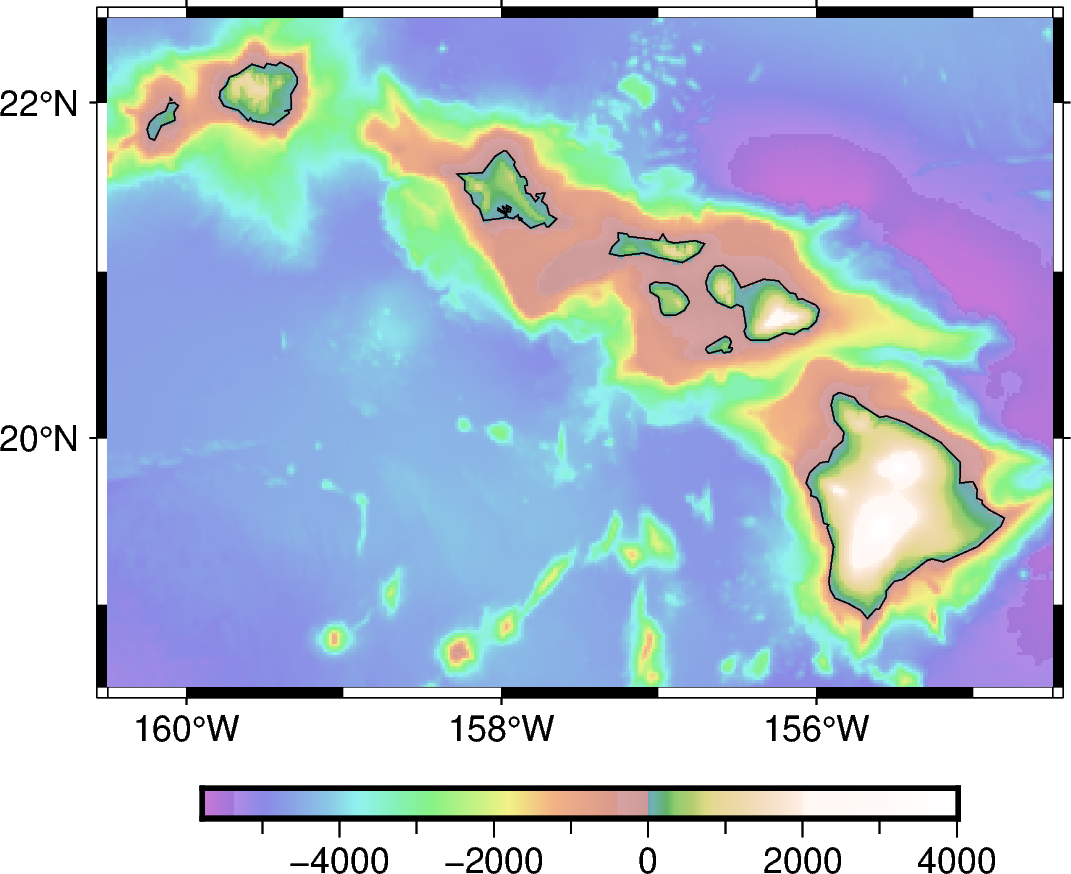

In [ ]:
from pygmt.datasets import load_earth_relief

# set region boundaries
west_lon = -160.5
east_lon = -154.5
south_lat = 18.5
north_lat = 22.5

sel_region=[west_lon, east_lon, south_lat, north_lat] # putting into 1 array

grid = load_earth_relief(region=sel_region,
                         resolution='01m') # grid resolution; 01m = 1 arc-minute (approx. 1.85 km)

fig3a = pygmt.Figure()
fig3a.basemap(region=sel_region, projection='M8c', frame=True)
fig3a.grdimage(grid, cmap='topo') # plot grid using terra / topo colormap
fig3a.coast(resolution='i', shorelines=True) # overlay coastlines on top
fig3a.colorbar() # add colorbar
fig3a.show()

gmtread [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]
gmtread [NOTICE]: SRTM15 Earth Relief v2.7 at 30x30 arc minutes reduced by Gaussian Cartesian filtering (157.3 km fullwidth) [Tozer et al., 2019].
gmtread [NOTICE]:   -> Download grid file [382K]: earth_relief_30m_g.grd


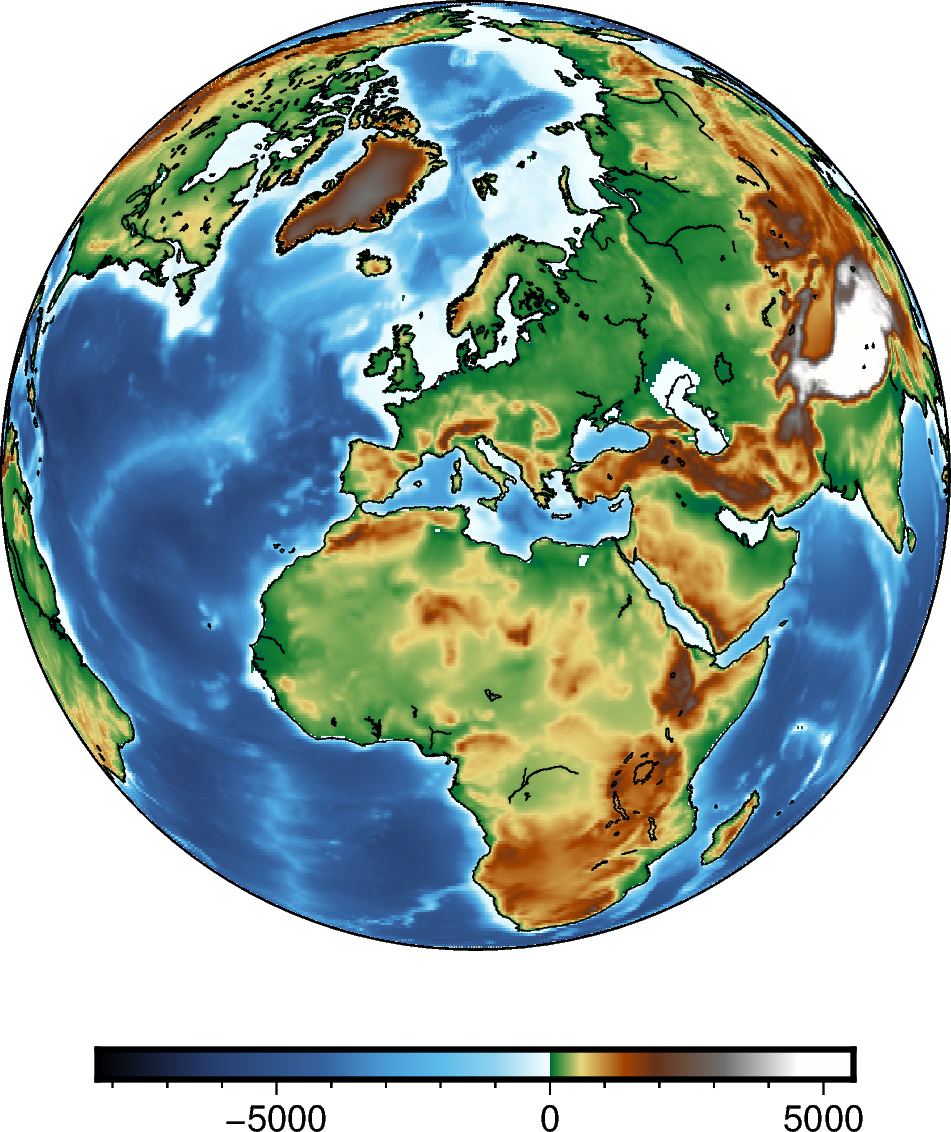

In [ ]:
global_grid = load_earth_relief(resolution='30m')
  # 30 arc-minute global Earth Relief grid (topography & bathymetry)

fig3b = pygmt.Figure()
fig3b.basemap(region='g', projection='G12/41/8c', frame=True)
  # basemap for global orthographic/stereographic projection
  # g = whole global region
  # G12/41/8c geostationary projection centered at 123°E, 11°N; 8 cm width
      # centered in rome, italy
fig3b.grdimage(global_grid, cmap='geo')
  # plot of gridded relief data
  # colorways: topo, terra, geo
fig3b.coast(resolution='i', shorelines=True, area_thresh=1000)
  # coastlines over elevation image using an "intermediate" map resolution
  # threshold: filtering ot bodies of water under 1,000 km² to keep the map clean.
fig3b.colorbar() # legend bar to show elev/depth of colors
fig3b.show()


## Example 4

There are also other built-in datasets for the other terrestrial planets:

gmtread [NOTICE]: Remote data courtesy of GMT data server oceania [http://oceania.generic-mapping-tools.org]
gmtread [NOTICE]: MOLA Mars Relief at 30x30 arc minutes reduced by Gaussian Cartesian filtering (83.8 km fullwidth) [Neumann et al., 2003].
gmtread [NOTICE]:   -> Download grid file [374K]: mars_relief_30m_g.grd


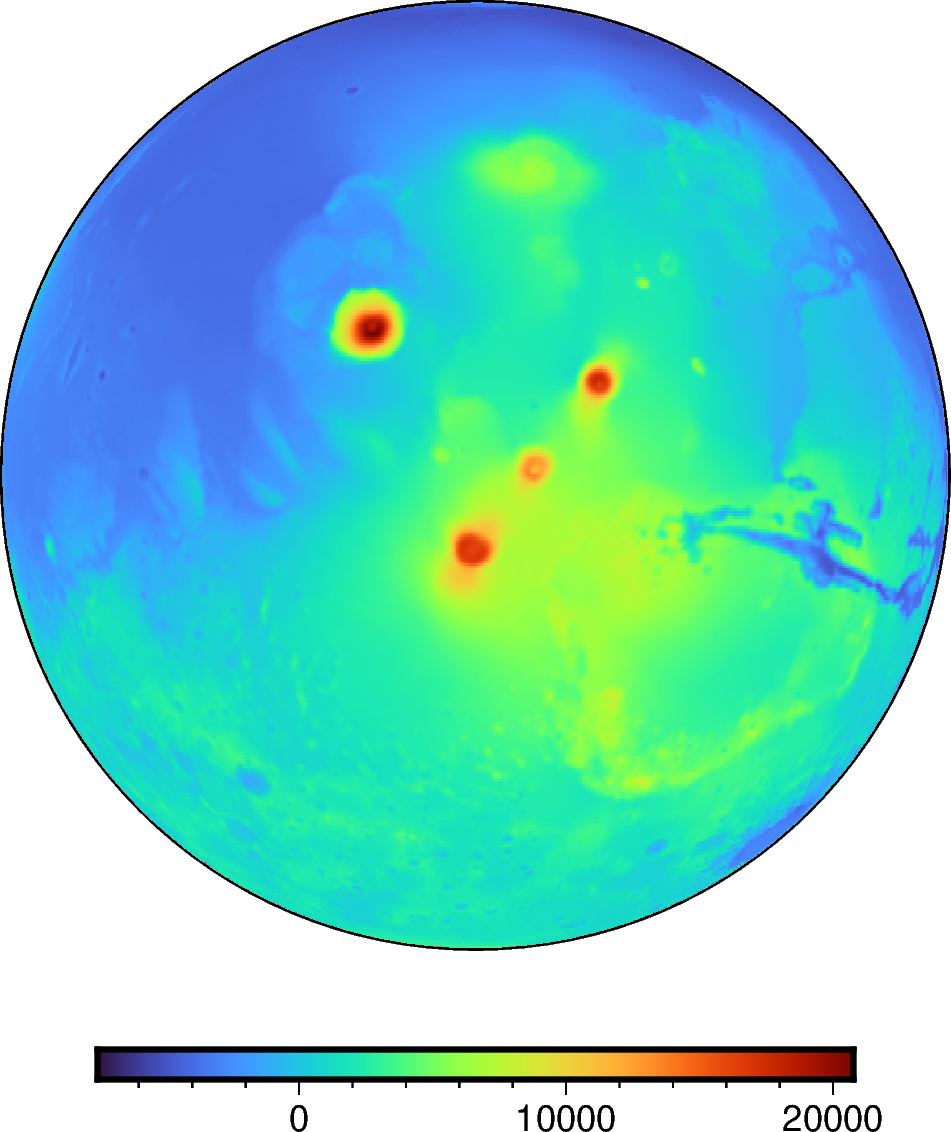

In [ ]:
from pygmt.datasets import load_mars_relief

mars_grid = load_mars_relief(resolution="30m")

fig4a = pygmt.Figure()
fig4a.basemap(region='g', projection='G240/0/8c', frame=True)
  # G240/0/8c geostationary projection centered at 240°E, 0°N; 8 cm width
fig4a.grdimage(mars_grid)
fig4a.colorbar()
fig4a.show()

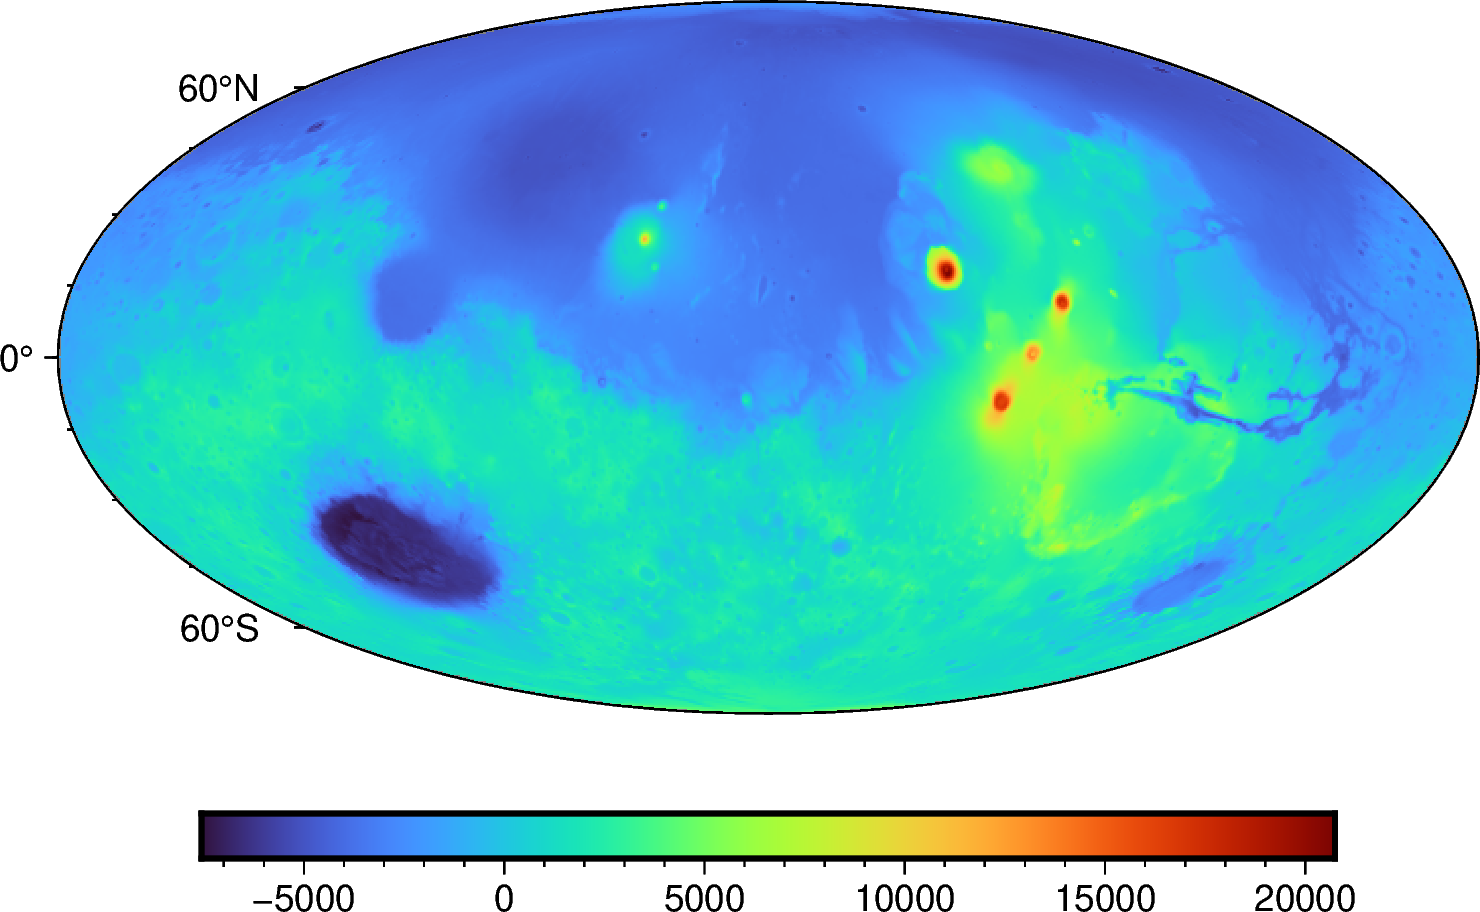

In [ ]:
# The following is in Molleweide projection

fig4b = pygmt.Figure()
fig4b.basemap(region='g', projection='W12c', frame=True)
  # W = global map of coastlines thats 12 cm wide using Mollweide projection
fig4b.grdimage(mars_grid)
fig4b.colorbar()
fig4b.show()

## Experiment for yourself

Uncomment the lines in the cell below and try making a figure based on the examples above.

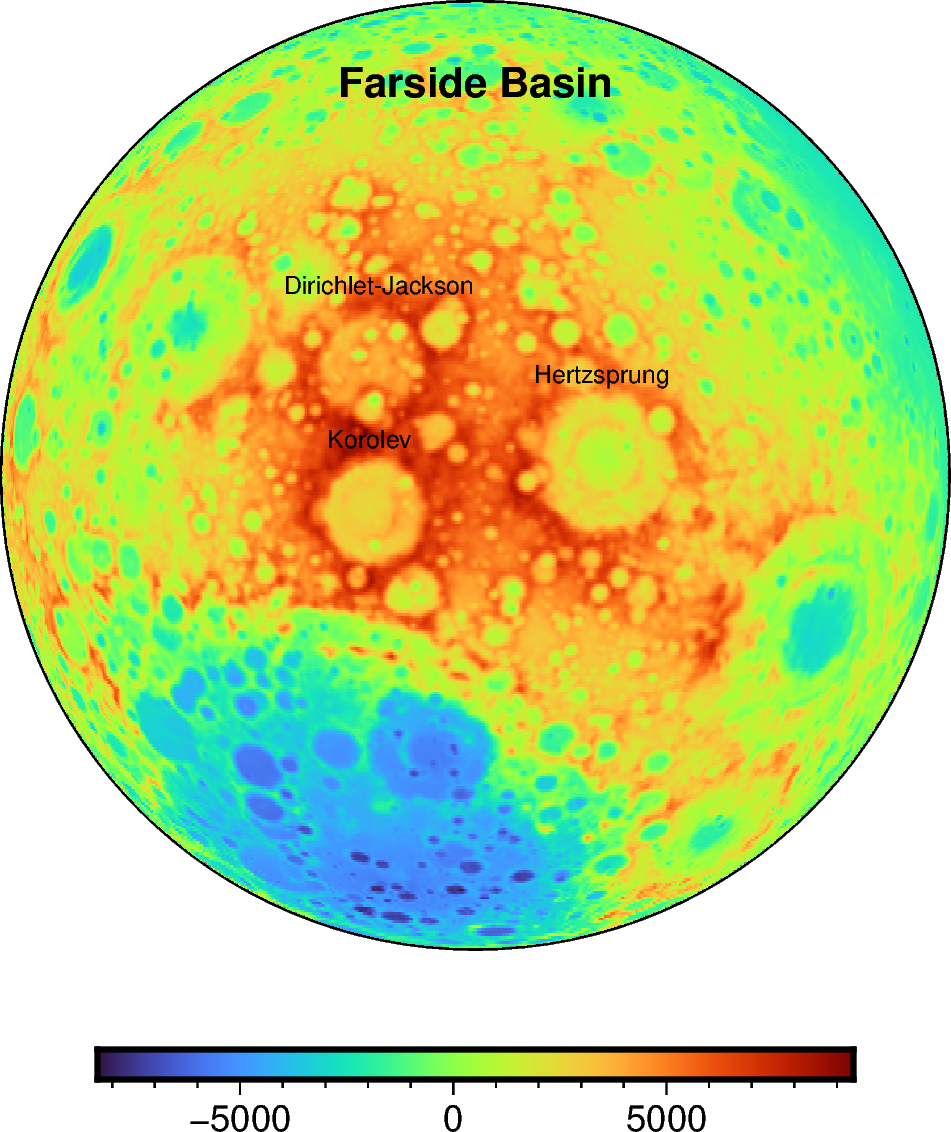

In [ ]:
from pygmt.datasets import load_moon_relief

moona_grid = load_moon_relief(resolution="30m")

fig5a = pygmt.Figure()
fig5a.basemap(region='g', projection='G215/0/8c', frame=True)
  # G240/0/8c geostationary projection centered at 240°E, 0°N; 8 cm width
fig5a.grdimage(moona_grid)
fig5a.colorbar()
fig5a.text(x=215, y=60, text="Farside Basin", font="10,Helvetica-Bold,black", justify="TC")
fig5a.text(x=202, y=25, text="Dirichlet-Jackson", font="6,Helvetica,black", justify="TC")
fig5a.text(x=202, y=5.5, text="Korolev", font="6,Helvetica,black", justify="TC")
fig5a.text(x=231, y=13.5, text="Hertzsprung", font="6,Helvetica,black", justify="TC")
fig5a.show()
fig5a.savefig('fig5a.png')

# references: https://the-moon.us/wiki/Lunar_Basins_List

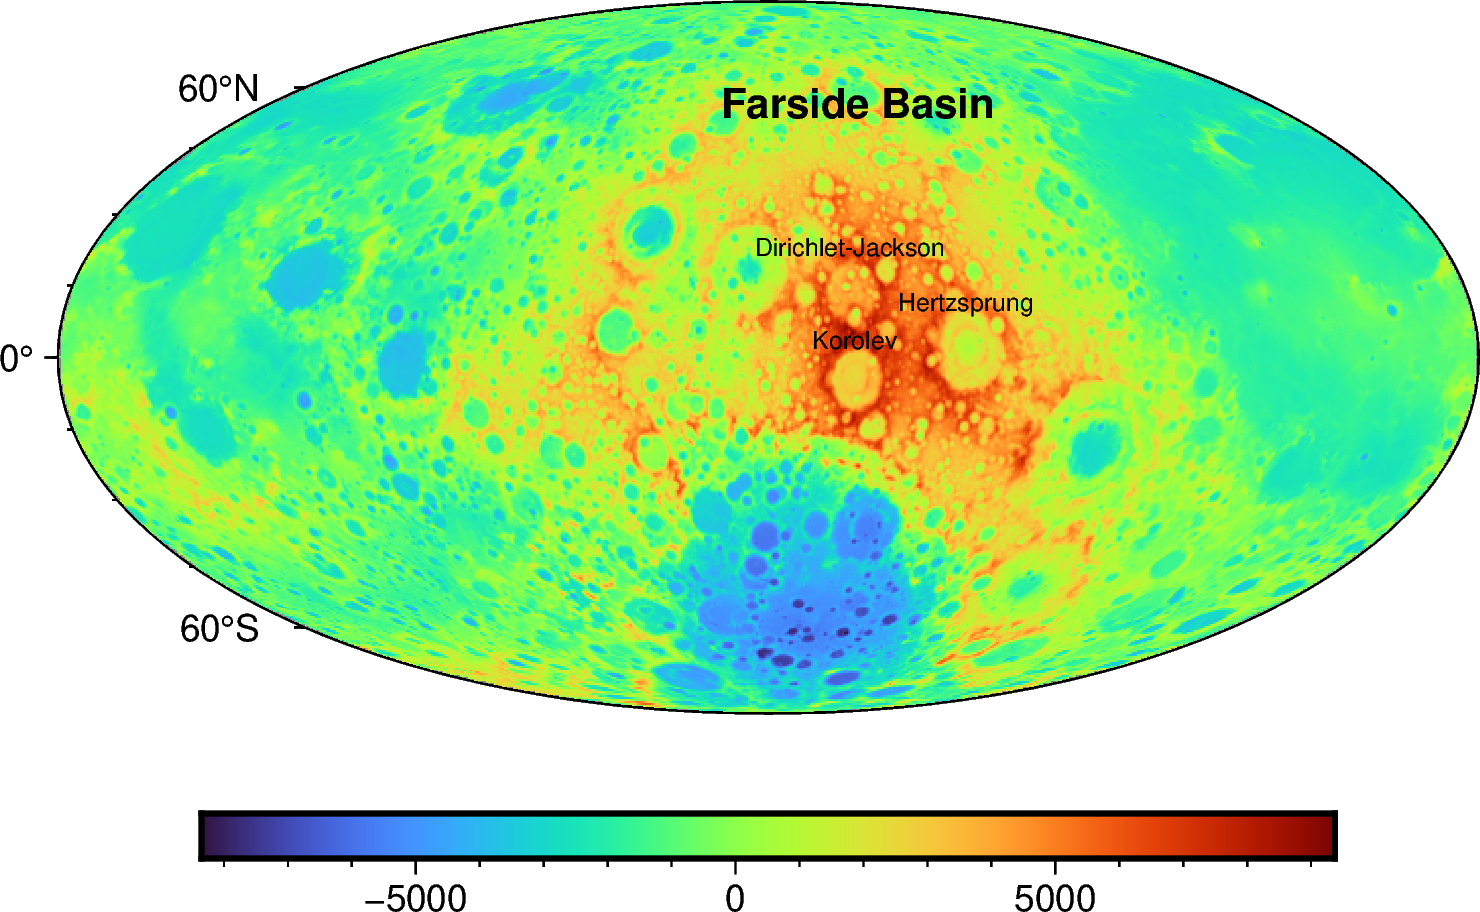

In [ ]:
from pygmt.datasets import load_moon_relief

moonb_grid = load_moon_relief(resolution="30m")

fig5b = pygmt.Figure()
fig5b.basemap(region='g', projection='W12c', frame=True)
  # G240/0/8c geostationary projection centered at 240°E, 0°N; 8 cm width
fig5b.grdimage(moonb_grid)
fig5b.colorbar()
fig5b.text(x=215, y=60, text="Farside Basin", font="10,Helvetica-Bold,black", justify="TC")
fig5b.text(x=202, y=25, text="Dirichlet-Jackson", font="6,Helvetica,black", justify="TC")
fig5b.text(x=202, y=5.5, text="Korolev", font="6,Helvetica,black", justify="TC")
fig5b.text(x=231, y=13.5, text="Hertzsprung", font="6,Helvetica,black", justify="TC")
fig5b.show()
fig5b.savefig('fig5b.png')

**NOTE:** If you want to keep any changes you make to this notebook, remember to select "File"->"Save". You can also save a copy of this notebook to your computer by selecting "File"->"Download".

## Resources

Here are some quick links to the PyGMT and GMT documentation:


*   [Color chart](https://docs.generic-mapping-tools.org/6.5/_images/GMT_RGBchart.png)
* [Map projections](https://www.pygmt.org/v0.6.0/projections/index.html)
* [Color palette chart](https://docs.generic-mapping-tools.org/6.5/reference/cpts.html)
* [Tutorial on coastlines and borders](https://www.pygmt.org/latest/tutorials/basics/coastlines.html#sphx-glr-tutorials-basics-coastlines-py)
* [Tutorial on frames, ticks, titles, and labels](https://www.pygmt.org/latest/tutorials/basics/frames.html#sphx-glr-tutorials-basics-frames-py)
* [Tutorial on setting the region](https://www.pygmt.org/latest/tutorials/basics/regions.html#sphx-glr-tutorials-basics-regions-py)
* [PyGMT API reference](https://www.pygmt.org/v0.6.0/api/index.html)
* [Datasets available in PyGMT](https://www.pygmt.org/latest/api/index.html#datasets)


This notebook combines material from the following tutorials:

*   [Try PyGMT on Google Colab](https://colab.research.google.com/github/GenericMappingTools/try-gmt/blob/main/python-demo-google-colab.ipynb)
* [Making your first figure](https://www.pygmt.org/v0.6.0/get-started/first_figure.html)

If you want to learn more, head to the official website at: https://www.pygmt.org